# WORK SPACE

## Baseline Autoencoder - Colon

In [3]:
import os
import sys

# Go one level up from notebooks/
PROJECT_ROOT = os.path.abspath("..")
sys.path.insert(0, PROJECT_ROOT)

from src.models.autoencoder import AutoEncoder

In [4]:
#imports
import torch
import pandas as pd
from torch.utils.data import DataLoader, TensorDataset

from src.models.autoencoder import AutoEncoder

In [6]:
# Load dataset
df = pd.read_csv("../data/preprocessed/colon.csv")

# Keep only features
X = df.drop(columns=["label"])

# Convert to PyTorch tensor
X = torch.tensor(X.values, dtype=torch.float32)

# Create DataLoader
dataset = TensorDataset(X)
train_loader = DataLoader(dataset, batch_size=16, shuffle=True)

print(X.shape)

torch.Size([62, 2000])


Tarining data is Ready

In [7]:
# Create model
input_dim = X.shape[1]
hidden_dim = 128

model = AutoEncoder(input_dim, hidden_dim)

# Loss function and optimizer
criterion = torch.nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

print(model)

AutoEncoder(
  (encoder): Sequential(
    (0): Linear(in_features=2000, out_features=128, bias=True)
    (1): ReLU()
  )
  (decoder): Sequential(
    (0): Linear(in_features=128, out_features=2000, bias=True)
  )
)


Model, data, loss function, and optimizer are ready.

In [8]:
# Train model
num_epochs = 50
losses = []

model.train()

for epoch in range(num_epochs):
    epoch_loss = 0

    for (batch,) in train_loader:
        optimizer.zero_grad()

        output = model(batch)
        loss = criterion(output, batch)

        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    losses.append(avg_loss)

    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {avg_loss:.4f}")

Epoch 1/50, Loss: 2.5109
Epoch 2/50, Loss: 2.2501
Epoch 3/50, Loss: 1.9697
Epoch 4/50, Loss: 1.6853
Epoch 5/50, Loss: 1.4714
Epoch 6/50, Loss: 1.3455
Epoch 7/50, Loss: 1.2700
Epoch 8/50, Loss: 1.2119
Epoch 9/50, Loss: 1.1582
Epoch 10/50, Loss: 1.1003
Epoch 11/50, Loss: 1.0375
Epoch 12/50, Loss: 0.9829
Epoch 13/50, Loss: 0.9291
Epoch 14/50, Loss: 0.8837
Epoch 15/50, Loss: 0.8392
Epoch 16/50, Loss: 0.8006
Epoch 17/50, Loss: 0.7698
Epoch 18/50, Loss: 0.7334
Epoch 19/50, Loss: 0.7061
Epoch 20/50, Loss: 0.6862
Epoch 21/50, Loss: 0.6667
Epoch 22/50, Loss: 0.6638
Epoch 23/50, Loss: 0.6565
Epoch 24/50, Loss: 0.6310
Epoch 25/50, Loss: 0.6026
Epoch 26/50, Loss: 0.6054
Epoch 27/50, Loss: 0.5602
Epoch 28/50, Loss: 0.5384
Epoch 29/50, Loss: 0.5179
Epoch 30/50, Loss: 0.5057
Epoch 31/50, Loss: 0.4868
Epoch 32/50, Loss: 0.4650
Epoch 33/50, Loss: 0.4468
Epoch 34/50, Loss: 0.4337
Epoch 35/50, Loss: 0.4211
Epoch 36/50, Loss: 0.4061
Epoch 37/50, Loss: 0.4096
Epoch 38/50, Loss: 0.3907
Epoch 39/50, Loss: 0.

#### plot the loss

FileNotFoundError: [Errno 2] No such file or directory: 'reports/figures/colon_baseline_loss.png'

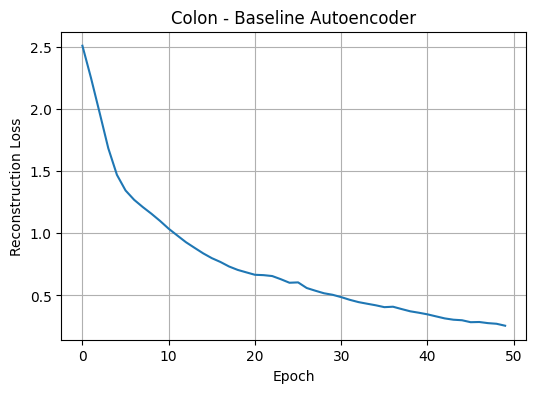

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Reconstruction Loss")
plt.title("Colon - Baseline Autoencoder")
plt.grid(True)

plt.savefig("../reports/figures/colon_baseline_loss.png")
plt.show()

During the training of the baseline autoencoder, the reconstruction loss started at about **2.5** in the first epoch because the model had not learned anything yet. As the training continued, the loss decreased quickly during the first 10 epochs, showing that the model was learning the main patterns in the data. Between epochs 10 and 20, the loss continued to decrease but at a slower rate. Around epoch 20, there was a small increase in the loss, but this was only temporary, and the loss continued to decrease afterwards. By the end of 50 epochs, the reconstruction loss had reduced to about **0.25**, showing that the model had learned to reconstruct the input data much better. Overall, the model trained successfully and showed a steady improvement throughout the training process.


 - Loss plot generated successfully
 - Initial loss was apprix 2.5
 - Final loss approx 0.2
 - Stable convergance
 - No training instability
